<a href="https://colab.research.google.com/github/upohaar/python-practice/blob/main/tania%20mam's%20hw.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Model Intercept: 146.59
                   Coefficient
Daily Active Mins     3.477844
Support Tickets     -12.214730
Features Used        24.914143
Team Size            40.276696
MAE  : 39.75 $
RMSE : 49.00 $
R²   : 99.27%


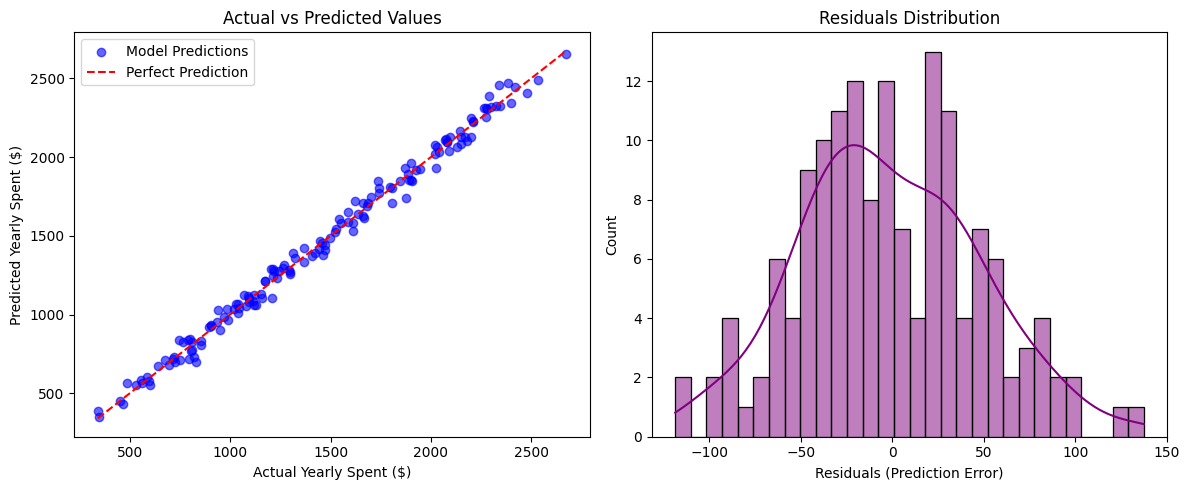

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

np.random.seed(42)
num_samples = 500

daily_active_mins = np.random.normal(loc=45, scale=15, size=num_samples).clip(5, 120)
support_tickets = np.random.poisson(lam=4, size=num_samples)
features_used = np.random.randint(1, 15, size=num_samples)
team_size = np.random.randint(1, 50, size=num_samples)


yearly_spent = (
    150
    + (daily_active_mins * 3.5)
    - (support_tickets * 12.0)
    + (features_used * 25.0)
    + (team_size * 40.0)
    + np.random.normal(0, 50, size=num_samples)
)

df = pd.DataFrame({
    'Daily Active Mins': np.round(daily_active_mins, 2),
    'Support Tickets': support_tickets,
    'Features Used': features_used,
    'Team Size': team_size,
    'Yearly Subscription Spent': np.round(yearly_spent, 2)
})

df.to_csv("saas_customer_data.csv", index=False)

X = df[['Daily Active Mins', 'Support Tickets', 'Features Used', 'Team Size']]
y = df['Yearly Subscription Spent']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

lm = LinearRegression()
lm.fit(X_train, y_train)

print(f"Model Intercept: {lm.intercept_:.2f}")

coeff_df = pd.DataFrame(lm.coef_, X.columns, columns=['Coefficient'])
print(coeff_df)

prediction = lm.predict(X_test)

mae = metrics.mean_absolute_error(y_test, prediction)
mse = metrics.mean_squared_error(y_test, prediction)
rmse = np.sqrt(mse)
r2 = metrics.r2_score(y_test, prediction)

print(f"MAE  : {mae:.2f} $")
print(f"RMSE : {rmse:.2f} $")
print(f"R²   : {r2 * 100:.2f}%")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, prediction, alpha=0.6, color='blue', label='Model Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
plt.xlabel('Actual Yearly Spent ($)')
plt.ylabel('Predicted Yearly Spent ($)')
plt.title('Actual vs Predicted Values')
plt.legend()

plt.subplot(1, 2, 2)
residuals = y_test - prediction
sns.histplot(residuals, kde=True, color='purple', bins=30)
plt.xlabel('Residuals (Prediction Error)')
plt.title('Residuals Distribution')

plt.tight_layout()
plt.show()